In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression 
import seaborn as sns
import tensorflow as tf

In [4]:
x = np.random.random(10000)
y = np.sqrt(1+x)

In [5]:
ones = np.ones(x.shape[0])[:,np.newaxis]

In [6]:
# Concat vector of ones 
X = np.concatenate([ones,x[:,np.newaxis]],axis = 1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

In [8]:
w_closed = np.linalg.inv(X_train.T.dot(X_train)).dot(X_train.T).dot(y_train)

In [9]:
def loss(X,y,w):
    return np.mean((X.dot(w)-y)**2)

# Loss for closed form solution

In [10]:
trainloss = loss(X_train,y_train,w_closed)
valloss = loss(X_val,y_val,w_closed)
testloss = loss(X_test,y_test,w_closed)

In [11]:
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))


Train loss: 2.743813466343425e-05
Val loss: 2.7090883752290894e-05
Test loss: 2.7508190868454873e-05


In [12]:
w_closed

array([1.01324638, 0.4115147 ])

In [13]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [15]:
w_sklearn = lr.coef_
w_sklearn[0] = lr.intercept_

# Loss for sklearn solution

In [14]:
trainloss = loss(X_train,y_train,w_sklearn)
valloss = loss(X_val,y_val,w_sklearn)
testloss = loss(X_test,y_test,w_sklearn)

In [15]:
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))


Train loss: 2.7809065910899877e-05
Val loss: 2.7534584233643354e-05
Test loss: 2.631322457626737e-05


In [21]:
class GradDescent:
    def __init__(self, alpha = 1e-3, max_iter = 10000, eps = 1e-8):
        self.alpha = alpha
        self.max_iter = max_iter
        self.eps = eps
    def train(self,X,y):
        self.w = np.random.uniform(-1,1,X.shape[1])
        i = 0
        w_cur = self.w
        diff = 1e6
        while (i<self.max_iter) and (diff>self.eps):
            if i%100==0:
                print("Iteration: {}, Loss: {}".format(i,loss(X,y,w_cur)))
            w_new = w_cur-self.alpha*(2*(X.T.dot(X).dot(w_cur)-X.T.dot(y)))
            diff = np.linalg.norm(w_new - w_cur)
            w_cur = w_new
            i+=1
        self.w = w_cur
        self.loss = loss(X,y,self.w)

In [22]:
gd = GradDescent(alpha = 1e-4,max_iter=2000)

In [23]:
gd.train(X_train,y_train)

Iteration: 0, Loss: 0.47309431600938057
Iteration: 100, Loss: 2.781085658572772e-05


In [24]:
w_grad = gd.w
w_grad

array([1.01312906, 0.41157293])

# Loss for gradient descent

In [25]:
trainloss = loss(X_train,y_train,w_grad)
valloss = loss(X_val,y_val,w_grad)
testloss = loss(X_test,y_test,w_grad)
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))

Train loss: 2.780906591174074e-05
Val loss: 2.753457486283331e-05
Test loss: 2.6313215531482534e-05


In [43]:
class TensorflowGradDescent:
    def __init__(self, alpha=1e-4, max_iter = 10000, eps=1e-8):
        self.max_iter = max_iter
        self.eps = eps
        self.alpha = alpha
        self.w = tf.Variable(tf.random.uniform(shape=(2, 1), minval=-1, maxval=1), 
                             dtype=tf.float32)
        self.loss = tf.keras.losses.MeanSquaredError()
    def train(self,X,y):
        X = tf.convert_to_tensor(X, dtype=tf.float32)
        y = tf.convert_to_tensor(y, dtype=tf.float32)
        i = 0
        diff = 1e6
        while (i<self.max_iter) and (diff>self.eps):
            w_old = self.w.numpy()
            if i%100==0:
                print("Iteration: {}, Loss: {}".format(i,loss(X.numpy(),y.numpy(),w_old)))
            with tf.GradientTape() as tape:
                pred = tf.matmul(X, self.w)
                model_loss = tf.reduce_sum((y[:, tf.newaxis] - pred) ** 2)
            grad = tape.gradient(model_loss, self.w)
            self.w.assign_sub(grad * self.alpha)
            w_new = self.w.numpy()
            diff = np.linalg.norm(w_new - w_old)
            i+=1
        

In [44]:
tensorflow_descent = TensorflowGradDescent(max_iter=2000)
tensorflow_descent.train(X_train, y_train)

Iteration: 0, Loss: 5.092686653137207
Iteration: 100, Loss: 0.02845809794962406


In [45]:
w_tf_descent = tensorflow_descent.w.numpy()[:, 0]

# Loss for tensorflow gradient descent

In [18]:
trainloss = loss(X_train,y_train,w_tf_descent)
valloss = loss(X_val,y_val,w_tf_descent)
testloss = loss(X_test,y_test,w_tf_descent)
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))

NameError: name 'w_tf_descent' is not defined

In [19]:
linear_regression_tf = tf.keras.Sequential([
    tf.keras.layers.Dense(1, use_bias=False, input_shape=(2,), 
                          kernel_initializer=tf.keras.initializers.RandomUniform(-1, 1))
    ])

In [30]:
linear_regression_tf.compile(loss=tf.keras.losses.MeanSquaredError(
    reduction=tf.keras.losses.Reduction.SUM),
                             optimizer=tf.keras.optimizers.SGD(1e-4))

In [27]:
linear_regression_tf.fit(X_train, y_train, epochs=200, batch_size=len(X_train))

Epoch 1/200
1/1 [==============================] - 0s 452ms/step - loss: 0.1646
Epoch 2/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 3/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1647
Epoch 4/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 5/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 6/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 7/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 8/200
1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 9/200
1/1 [==============================] - 0s 6ms/step - loss: 0.1646
Epoch 10/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 11/200
1/1 [==============================] - 0s 6ms/step - loss: 0.1646
Epoch 12/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 13/200
1/1 [==============================] - 0s 4ms/

1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 105/200
1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 106/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 107/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 108/200
1/1 [==============================] - 0s 8ms/step - loss: 0.1646
Epoch 109/200
1/1 [==============================] - 0s 6ms/step - loss: 0.1646
Epoch 110/200
1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 111/200
1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 112/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 113/200
1/1 [==============================] - 0s 3ms/step - loss: 0.1646
Epoch 114/200
1/1 [==============================] - 0s 5ms/step - loss: 0.1646
Epoch 115/200
1/1 [==============================] - 0s 4ms/step - loss: 0.1646
Epoch 116/200
1/1 [==============================] - 0

In [37]:
w_tf = linear_regression_tf.layers[0].weights[0].numpy()[:, 0]

In [38]:
w_tf

<tf.Variable 'dense/kernel:0' shape=(2, 1) dtype=float32, numpy=
array([[1.0132464 ],
       [0.41151473]], dtype=float32)>

# Loss for tensorflow

In [34]:
trainloss = loss(X_train,y_train,w_tf)
valloss = loss(X_val,y_val,w_tf)
testloss = loss(X_test,y_test,w_tf)
print("Train loss: {}".format(trainloss))
print("Val loss: {}".format(valloss))
print("Test loss: {}".format(testloss))

Train loss: 2.780906591442975e-05
Val loss: 2.75346048644732e-05
Test loss: 2.631323509058201e-05


In [35]:
xaxis = np.linspace(0,1,10000)

/home/work/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/work/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/work/.local/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/work/.l

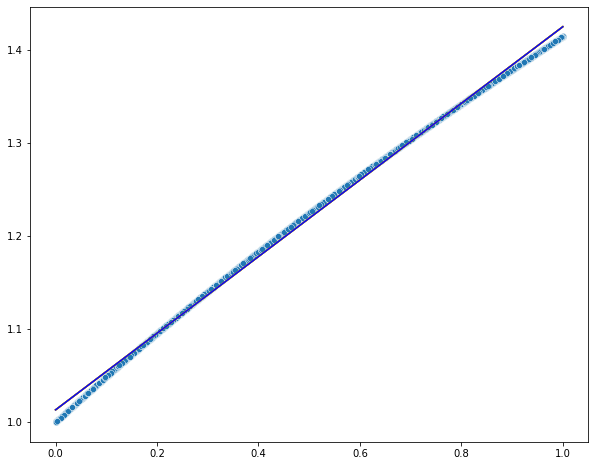

In [36]:
fig,ax = plt.subplots(figsize=(10,8))
sns.scatterplot(X[:,1],y,ax=ax)
sns.lineplot(xaxis,w_closed[0]+w_closed[1]*xaxis,color = "red")
sns.lineplot(xaxis,w_sklearn[0]+w_sklearn[1]*xaxis,color = "green")
sns.lineplot(xaxis,w_grad[0]+w_grad[1]*xaxis,color = "yellow")
sns.lineplot(xaxis,w_tf_descent[0]+w_tf_descent[1]*xaxis,color = "orange")
sns.lineplot(xaxis,w_tf[0]+w_tf[1]*xaxis,color = "blue")

plt.show()

In [39]:
print("Closed from solution: w0 = {}, w1 = {}".format(*w_closed))
print("Sklearn solution: w0 = {}, w1 = {}".format(*w_sklearn))
print("Gradient descent solution: w0 = {}, w1 = {}".format(*w_grad))
print("Tensorflow gradient descent solution: w0 = {}, w1 = {}".format(*w_tf_descent))
print("Tensorflow solution: w0 = {}, w1 = {}".format(*w_tf))

Closed from solution: w0 = 1.0131291174142976, w1 = 0.4115728269884862
Sklearn solution: w0 = 1.013129117414298, w1 = 0.41157282698848624
Gradient descent solution: w0 = 1.0131290642306288, w1 = 0.41157292633900605
Tensorflow gradient descent solution: w0 = 1.0131289958953857, w1 = 0.41157302260398865
Tensorflow solution: w0 = 1.0131292343139648, w1 = 0.4115726351737976


## We have all of the solution very close to each other

## Taylor first order approximation for $\sqrt{1+x}$ at 0 is $1+\frac{1}{2}x$ and is accurate when we take a look at values which are pretty close to 0
## In our case for values around 1 the Taylor approximation is not very accurate 
## Doing linear regression it tries to be close also for that values, so the line inclines towards that direction and the slope decreases a little bit 
## If we took not the range [0,1] but [0,0.1] the linear regression result would be much closer to Taylor first order approximation

# Polynomial regression

$y_i = w_0+w_1x_{i1}+w_2x_{i2}+w_3x_{i1}^2+w_4x_{i2}^2+w_5x_{i1}x_{i2}+\epsilon_{i}$

The same way we can define polynomials of higher order

To solve polynomial regression problem we will just need to concatenate new feature such as $x_1^2$ or $x_1*x_2$, we will get a new matrix with higher dimension and the solution will be the same :
$(X^TX)^{-1}X^Ty$